# Super-resolution avec un Efficient Sub-Pixel CNN

## Sources

La théorie provient de l'article d'origine de [Wenzhe Shi, 2016](https://arxiv.org/abs/1609.05158) sur le ESPCN (Efficient Sub-Pixel CNN)

Les codes proviennent en majorité de ce notebook d'origine : *Image Super-Resolution using an Efficient Sub-Pixel CNN*

**Author:** [Xingyu Long](https://github.com/xingyu-long)<br>
**Date created:** 2020/07/28<br>
**Last modified:** 2020/08/27<br>
**Description:** Implementing Super-Resolution using Efficient sub-pixel model on BSDS500.

## Configuration

### Google Drive

In [ ]:
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


In [ ]:
import os

DIR_FOR_DATA = os.path.join("/", "gdrive", "My Drive", "deep_data")

if not os.path.exists(DIR_FOR_DATA):
  os.makedirs(DIR_FOR_DATA)

os.chdir(DIR_FOR_DATA)

print(os.getcwd())

/gdrive/My Drive/deep_data


### Python

In [ ]:
import math
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Quelques fonctions qui nous seront utiles :
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory

from IPython.display import Image, display

## Théorie

### Introduction

La **super-résolution** (SR) consiste à générer une version haute résolution (HR) d'une image en partant de données en basse résolution (LR).

Il y a de nombreux champs d'application : HDTV, imagerie médicale, imagerie satellite, reconnaissance faciale, surveillance...

Pour justifier que la super-résolution est théoriquement possible, l'auteur écrit ceci :

*A key assumption that underlies
many SR techniques is that much of the high-frequency data
is redundant and thus can be accurately reconstructed from
low frequency components. SR is therefore an inference
problem, and thus relies on our model of the statistics of
images in question.*

Autrement dit : la plupart des images contiennent beaucoup de redondances. On devrait donc pouvoir exploiter des informations en basse résolution pour reproduire ces redondances et générer des images en haute résolution crédibles.

On peut faire de la super-résolution à partir de plusieurs images, mais ici on s'intéressera à une méthode de type **SISR** (single image super-resolution), qui n'utilise qu'une seule image en entrée.

### Single image super resolution (SISR)

On considère deux espaces pour nos images

* Un espace $\text{LR}$ où vivent des images basse résolution de taille $H \times W \times C$
* Un espace $\text{HR}$ où vivent des images haute résolution de taille $(r \cdot H) \times (r \cdot W) \times C$

où
* $r \in \mathbb{N}^*$ est un facteur d'agrandissement, aussi appelé `upscale_factor`
* $C$ est le nombre de channels des images.

On part d'une image basse résolution $\text{I}^{LR} \in \text{LR}$ et on voudrait utiliser une méthode de super-résolution pour obtenir une image $\text{I}^{SR} \in \text{HR}$.

Concrètement, l'image $\text{I}^{LR}$ qu'on utilisera sera générée en déteriorant une image haute résolution $\text{I}^{HR} \in \text{HR}$ avec une transformation connue.

### Efficient Sub-Pixel CNN (ESPCN)

Beaucoup de méthodes pour résoudre le problème SISR travaillent directement sur une version agrandie de $\text{I}^{LR}$ pour obtenir l'image haute résolution $\text{I}^{HR}$. Conséquence : beaucoup de calculs sont effectués dans l'espace $\text{HR}$...

Le modèle Efficient Sub-Pixel CNN (ESPCN) a été proposé par [Wenzhe Shi](https://arxiv.org/abs/1609.05158) en 2016. C'est un réseau de neurones qui travaille uniquement en basse résolution sans jamais avoir besoin d'agrandir la dimension de l'image donnée en entrée.

Le passage de $\text{LR}$ à $\text{HR}$ est effectué à la toute dernière couche du réseau : c'est le `sub_pixel convolution layer`.

À part cette toute dernière couche qui est un peu particulière, le réseau est une simple suite de convolutions 2D.

Notons $\text{I}^{LR} \in \text{LR}$ l'image d'entrée et supposons que le modèle possède $L$ couches.


#### Premières couches : couches convolutives ordinaires

Les $L-1$ premières couches $f^1 \cdots f^{L-1}$ couches peuvent être décrites ainsi :

$$
f^1(\text{I}^{LR}) = \phi(W_1*\text{I}^{LR}+b_1) \\
\cdots \\
f^l(\text{I}^{LR}) = \phi(W_l*f^{l-1}(\text{I}^{LR})+b_l)
$$

où

* $l = 1 \cdots L-1$
* $W_l$ est un noyau de convolution de taille $k_l$ qui opère un passage de $n_{l-1}$ à $n_l$ channels. Sa dimension est $(n_{l-1}, n_l, k_l, k_l)$
* $b_l$ est le biais appliqué après la convolution, de dimension $n_l$
* $n_0 = C$ est le nombre de channels de l'image de départ
* $\phi$ est une fonction d'activation non linéaire

Pour l'instant, on reste en basse résolution : à part le nombre de channels qui change, la largeur et la hauteur de l'image restent les mêmes.

#### Dernière couche : sub-pixel convolution layer

La couche $L$ est le **sub-pixel convolution layer**, chargé de produire l'image haute résolution $\text{I}^{SR} \in \text{HR}$.

C'est également une couche convolutive, mais la fonction d'activation est remplacée par un opérateur particulier. Cette dernière couche peut être décrite ainsi :

$$
\text{I}^{SR} = f^{L}(\text{I}^{LR}) = \mathcal{PS}(W_L*f^{L-1}(\text{I}^{LR})+b_L)
$$

où

* $W_L$ opère un passage de $n_{L-1}$ à $C \cdot r^2$ channels. Sa dimension est $(n_{L-1}, C \cdot r^2, k_L, k_L)$
* $b_L$ est un biais de longueur $r^2$
* $\mathcal{PS}$ (pour **"periodic shuffling"**) est un opérateur déterministe (sans aucun paramètre) qui réarrange les éléments d'un tenseur de dimension $H \times W \times (C \cdot r^2)$ en un tenseur de dimension $(r \cdot H) \times (r \cdot W) \times C$

On peut décrire précisément le fonctionnement de l'opérateur $\mathcal{PS}$ :

Si $T$ est un tenseur de dimension $H \times W \times (C \cdot r^2)$, le tenseur $\mathcal{PS}(T)$ de dimension $H \times W \times (C \cdot r^2)$ correspondant est défini par la formule :

$$
\mathcal{PS}(T)_{x,y,c} = T_{x', y', c'}
$$

avec (en supposant que les indices commencent à 0)

* $x' = \lfloor x/r \rfloor$
* $y' = \lfloor y/r \rfloor$
* $c' = C \cdot r \cdot mod(y,r) + C \cdot mod(x,r) + c$


Le réarangement des pixels avec l'opérateur $\mathcal{PS}$ est représenté dans la figure suivante :

<img src="https://miro.medium.com/max/2000/1*AnTunkGkz-KNTQkrezoSmQ.jpeg" width=1000 />

### Loss : Mean Square Error (MSE)

Pour entraîner notre modèle, nous générerons des images basses résolution à partir de fichiers sources haute résolution. Pour chaque image on note :

* $\text{I}^{HR}$ l'image d'origine
* $\text{I}^{LR}$ sa version basse résolution
* $\text{I}^{SR} = f^{L}(\text{I}^{LR})$ la prédiction haute résolution du modèle

On veut que $\text{I}^{SR}$ soit proche de $\text{I}^{HR}$.

Comme fonction loss $\ell$, on utilisera une erreur quadratique :

$$
\ell(\text{I}^{SR}) = \text{MSE}(\text{I}^{SR}) = \frac{1}{r^2HW} \sum_{x=1}^{rH} \sum_{y=1}^{rW} (\text{I}^{HR}_{x,y} - \text{I}_{x,y}^{SR})^2
$$

### Peak Signal to Noise Ratio (PSNR)

En plus de la loss, le **Peak Signal to Noise Ratio** [(PSNR)](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio) est une quantité intéressante à calculer. Le PNSR est utilisé pour mesurer la qualité de reconstruction de l'image compressée par rapport à l'image originale.

Le PSNR s'exprime en décibels (dB)

$$
\text{PSNR}(\text{I}^{SR}) = 10 \cdot log_{10} \left(\frac{\text{MAX}_{\text{I}^{HR}}^2}{\text{MSE}(\text{I}^{SR})}\right)
$$

où $\text{MAX}_{\text{I}^{HR}}$ est la **dynamique du signal** : c'est la valeur maximale que peuvent prendre les pixels de $\text{I}^{HR}$, typiquement $1$ ou $255$.

Ici nous travaillerons en flottants, donc on aura simplement $\text{MAX}_{\text{I}^{HR}}^2 = 1$.

Si la loss est grande, le PSNR est petit; si la loss est petite, le PSNR est grand.

## Données

### Jeu de données BSDS500

Nous utiliserons le Berkeley Segmentation Data Set 500 (BSDS500). C'est un jeu de 500 images souvent utilisé pour des tâches de détection de contours. Ici seules les images nous intéresseront.

On commence par charger les images dans Google Drive si ce n'est pas déjà fait.

In [ ]:
if not os.path.exists(os.path.join(DIR_FOR_DATA, "datasets")):

  data_dir = keras.utils.get_file(
      origin="http://www.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz",
      fname="BSR",
      untar=True,
      cache_dir=DIR_FOR_DATA
  )

root_dir = os.path.join(DIR_FOR_DATA, "datasets", "BSR", "BSDS500", "data")

On peut afficher la structure du dossier pour se faire une idée. Ici, seul le dossier ```images``` nous intéresse.

In [ ]:
def list_files(startpath):

    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for f in sorted(files)[:3]:
            print('{}{}'.format(subindent, f))


list_files(root_dir)

print()
print("len(train) =", len([fname for fname in os.listdir(os.path.join(root_dir, "images", "train")) if fname.endswith(".jpg")]))
print("len(val) =", len([fname for fname in os.listdir(os.path.join(root_dir, "images", "val")) if fname.endswith(".jpg")]))
print("len(test) =", len([fname for fname in os.listdir(os.path.join(root_dir, "images", "test")) if fname.endswith(".jpg")]))

data/
    images/
        test/
            100007.jpg
            100039.jpg
            100099.jpg
        val/
            101085.jpg
            101087.jpg
            102061.jpg
        train/
            100075.jpg
            100080.jpg
            100098.jpg
    groundTruth/
        train/
            100075.mat
            100080.mat
            100098.mat
        val/
            101085.mat
            101087.mat
            102061.mat
        test/
            100007.mat
            100039.mat
            100099.mat

len(train) = 200
len(val) = 100
len(test) = 200


### Traitement des images et création de datasets train et validation

Nous allons créer nos jeux de données en utilisant la classe ```tf.data.Dataset``` de Tensorflow. Cette classe permet de représenter un ensemble de données (potentiellement très grand) sans avoir à les charger en mémoire. Les données seront générées au fur et à mesure qu'on y accède.

Pour utiliser cette classe il faut d'abord définir la source des données. Plusieurs méthodes existent, par exemple

- ```from_generator```
- ```from_tensor_slices```

Ici on utilisera une autre méthode proposée dans Keras : `image_dataset_from_directory`. Cette nous permet déjà de regrouper les données par batch et d'appliquer une première transformation aux images (ici un simple redimensionnement pour que toutes les images aient la même taille $300 \times 300$).

In [ ]:
new_size = 300
upscale_factor = 3
input_size = new_size // upscale_factor
batch_size = 8

In [ ]:
train_ds = image_dataset_from_directory(
    os.path.join(root_dir, "images", "train"),
    batch_size=batch_size,
    image_size=(new_size, new_size),
    seed=1337,
    label_mode=None,
)

valid_ds = image_dataset_from_directory(
    os.path.join(root_dir, "images", "val"),
    batch_size=batch_size,
    image_size=(new_size, new_size),
    seed=1337,
    label_mode=None,
)

Found 200 files belonging to 1 classes.
Found 100 files belonging to 1 classes.


Une fois que c'est fait on peut définir toutes sortes de transformations sur nos données grâce à la méthode ```map``` qui permet de "plugger" nos données dans n'importe quelle fonction.

Ici, on va juste renormaliser les images pour que les valeurs des pixels soient entre $0$ et $1$.

In [ ]:
def to_float(input_image):

    input_image = input_image / 255.0
    return input_image


train_ds = train_ds.map(to_float)
valid_ds = valid_ds.map(to_float)

À ce stade les images ont toutes la même tailles mais sont encore en "haute résolution". On peut visualiser quelques images :

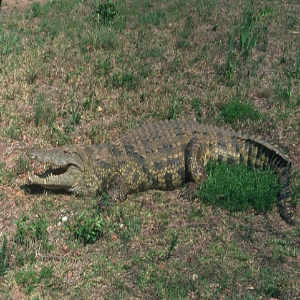

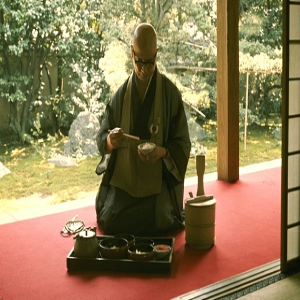

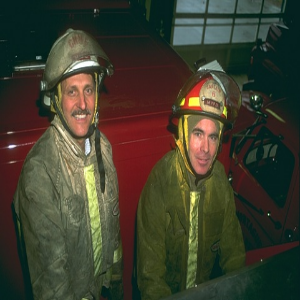

In [ ]:
batch = list(train_ds.take(1))[0]
images = batch[:3]

for image in images :
  display(array_to_img(image))

Let's process image data.
First, we convert our images from the RGB color space to the
[YUV colour space](https://en.wikipedia.org/wiki/YUV). *(luma, blue projection, red projection : similar to YCbCr)*

For the input data (low-resolution images),
we crop the image, retrieve the `y` channel (luninance),
and resize it with the `area` method (use `BICUBIC` if you use PIL).
We only consider the luminance channel
in the YUV color space because humans are more sensitive to
luminance change.

For the target data (high-resolution images), we just crop the image
and retrieve the `y` channel.

In [ ]:
# Use TF Ops to process.

def gen_xy(image) :

    image = tf.image.rgb_to_yuv(image)
    y, u, v = tf.split(image, 3, axis=-1)

    input = tf.image.resize(y, [input_size, input_size], method="area")

    target = y

    return input, target


train_ds = train_ds.map(gen_xy)
train_ds = train_ds.prefetch(buffer_size=32)

valid_ds = valid_ds.map(gen_xy)
valid_ds = valid_ds.prefetch(buffer_size=32)

### Récapitulons

On a effectués cette série d'opérations sur notre dataset :

* Chargement des images, redimensionnement, mélange, regroupement par batch avec la fonction `image_dataset_from_directory`
* Conversion des valeurs en flottants (entre $0$ et $1$) en mappant notre fonction `to_float` grâce à la méthode `map`
* Création des couples `(input, target)` en mappant notre fonction `gen_xy`
* Préchargement de données avec `prefetch`

`dataset = image_dataset_from_directory(...).map(...).map(...).prefetch(...)`

### Visualisation d'un exemple

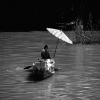

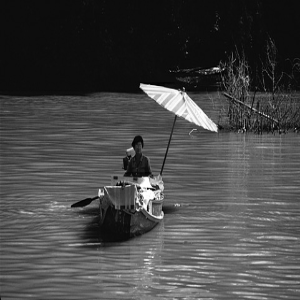

In [ ]:
batch = list(train_ds.take(1))[0]
input, target = batch[0][0], batch[1][0]

display(array_to_img(input))
display(array_to_img(target))

### Données test

Chargeons en mémoire les chemins des images test. On les utilisera pour générer des images basse résolution à évaluer avec notre modèle entraîné.

In [ ]:
test_path = os.path.join(root_dir, "images", "test")
test_img_paths = [os.path.join(test_path, fname) for fname in os.listdir(test_path) if fname.endswith(".jpg")]

print(f"Il y a {len(test_img_paths)} images test")

Il y a 200 images test


/gdrive/My Drive/deep_data/datasets/BSR/BSDS500/data/images/test/134049.jpg


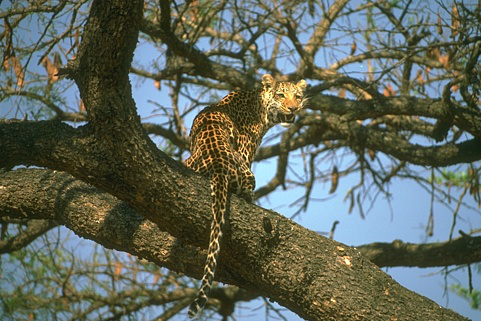

In [ ]:
k = 0
print(test_img_paths[k])
display(load_img(test_img_paths[k]))

## Implémentation et entraînement du réseau ESPCN

### Le modèle

Compared to the paper, we add one more layer and we use the `relu` activation function
instead of `tanh`.
It achieves better performance even though we train the model for fewer epochs.

In [ ]:
def get_model(upscale_factor=3, channels=1):

    conv_args = {
        "activation": "relu",
        "kernel_initializer": "Orthogonal",
        "padding": "same",
    }

    # (None, None, 1)
    inputs = keras.Input(shape=(None, None, channels))

    # (None, None, 64)
    x = layers.Conv2D(filters=64, kernel_size=5, **conv_args)(inputs)      # (5*5)*(1*64)+64 = 1664 params

    # (None, None, 64)
    x = layers.Conv2D(filters=64, kernel_size=3, **conv_args)(x)           # (3*3)*(64*64)+64 = 36928 params

    # (None, None, 32)
    x = layers.Conv2D(filters=32, kernel_size=3, **conv_args)(x)           # (3*3)*(64*32)+32 = 18464 params

    # Layer de "sub-pixel convolution" en deux étapes :
    # étape 1 : On effectue une dernière convolution pour arriver à upscale_factor^2 channels
    # étape 2 : On redistribue tous les pixels sur une image à un seul channel.
    # Ce qui se passe pour un seul pixel : (1,1,9) -> (3, 3, 1)
    # Un pixel à 9 channels devient un carré de 3 pixels de côté à un seul channel

    # (None, None, 3*3)
    x = layers.Conv2D(channels * (upscale_factor ** 2), 3, **conv_args)(x) # (3*3)*(32*9)+9 = 2601 params      (pas besoin de mettre une fonction d'activation?)

    # (3*None, 3*None, 1)
    outputs = tf.nn.depth_to_space(x, upscale_factor)                      # no parameters

    return keras.Model(inputs, outputs)


In [ ]:
keras.backend.clear_session()
get_model().summary()
keras.backend.clear_session()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 1)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 64)    1664      
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 64)    36928     
                                                                 
 conv2d_2 (Conv2D)           (None, None, None, 32)    18464     
                                                                 
 conv2d_3 (Conv2D)           (None, None, None, 9)     2601      
                                                                 
 tf.nn.depth_to_space (TFOpL  (None, None, None, 1)    0         
 ambda)                                                          
                                                             

### Des fonctions pour tester le modèle

We need to define several utility functions to monitor our results:

- `plot_results` to plot an save an image.
- `get_lowres_image` to convert an image to its low-resolution version.
- `upscale_image` to turn a low-resolution image to
a high-resolution version reconstructed by the model.
In this function, we use the `y` channel from the YUV color space
as input to the model and then combine the output with the
other channels to obtain an RGB image.

In [ ]:
PATH_FOR_HISTORY = os.path.join(DIR_FOR_DATA, "history")
if not os.path.exists(PATH_FOR_HISTORY):
    os.makedirs(PATH_FOR_HISTORY)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import PIL


def plot_results(img, prefix, title):

    """Plot the result with zoom-in area."""
    img_array = img_to_array(img)
    img_array = img_array.astype("float32") / 255.0

    # Create a new figure with a default 111 subplot.
    fig, ax = plt.subplots()
    im = ax.imshow(img_array[::-1], origin="lower")

    plt.title(title)
    # zoom-factor: 2.0, location: upper-left
    axins = zoomed_inset_axes(ax, 2, loc=2)
    axins.imshow(img_array[::-1], origin="lower")

    # Specify the limits.
    x1, x2, y1, y2 = 200, 300, 100, 200
    # Apply the x-limits.
    axins.set_xlim(x1, x2)
    # Apply the y-limits.
    axins.set_ylim(y1, y2)

    plt.yticks(visible=False)
    plt.xticks(visible=False)

    # Make the line.
    mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="blue")
    filename = str(prefix) + "-" + title + ".png"
    plt.savefig(os.path.join(PATH_FOR_HISTORY, filename))
    plt.show()


def get_lowres_image(img, upscale_factor):

    """Return low-resolution image to use as model input."""
    return img.resize(
        (img.size[0] // upscale_factor, img.size[1] // upscale_factor),
        PIL.Image.BICUBIC,
    )


def upscale_image(model, img):

    """Predict the result based on input image and restore the image as RGB."""
    ycbcr = img.convert("YCbCr")
    y, cb, cr = ycbcr.split()

    y = img_to_array(y)
    y = y.astype("float32") / 255.0
    input = np.expand_dims(y, axis=0)
    out = model.predict(input)
    out_img_y = out[0]
    out_img_y *= 255.0
    # Restore the image in RGB color space.
    out_img_y = out_img_y.clip(0, 255)
    out_img_y = out_img_y.reshape((np.shape(out_img_y)[0], np.shape(out_img_y)[1])) # (x, y, 1) -> (x,y)
    out_img_y = PIL.Image.fromarray(np.uint8(out_img_y), mode="L")

    out_img_cb = cb.resize(out_img_y.size, PIL.Image.BICUBIC) # on ne fait aucune prédiction sur la chroma bleue
    out_img_cr = cr.resize(out_img_y.size, PIL.Image.BICUBIC) # on ne fait aucune prédiction sur la chroma rouge
    out_img = PIL.Image.merge("YCbCr", (out_img_y, out_img_cb, out_img_cr)).convert("RGB")

    return out_img


### Des callbacks à appeler pendant l'entraînement

#### Early stopping

Si la loss n'a pas diminué en 10 epochs, on s'arrête.

In [ ]:
early_stopping_callback = keras.callbacks.EarlyStopping(monitor="loss", patience=10)

#### Checkpoints

On sauvegarde le modèle après chaque époque (seulement si c'est le meilleur)

In [ ]:
checkpoint_filepath = os.path.join(PATH_FOR_HISTORY, "checkpoint")

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor="loss",
    mode="min",
    save_best_only=True,
)

#### Peak signal-to-noise (PSNR)

On peut aussi créer des fonctions de callback personnalisées. Ici on se propose de calculer et d'afficher à chaque fin d'epoch le [PSNR](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio) (Peak signal-to-noise) des images générées par le modèle pour évaluer la performance de la super-résolution.

In [ ]:
class ESPCNCallback(keras.callbacks.Callback):

    def __init__(self):
        super().__init__()
        self.test_img = get_lowres_image(load_img(test_img_paths[0]), upscale_factor)

    # Store PSNR value in each epoch.
    def on_epoch_begin(self, epoch, logs=None):
        print("\n")
        self.psnr = []

    def on_test_batch_end(self, batch, logs=None):
        self.psnr.append(10 * math.log10(1 / logs["loss"]))

    def on_epoch_end(self, epoch, logs=None):
        # à chaque époque on affiche la moyenne de la loss
        print("Mean PSNR for epoch: %.2f" % (np.mean(self.psnr)))
        if epoch % 20 == 0:
            # toutes les 20 époques, on affiche la prédiction d'une image test
            prediction = upscale_image(self.model, self.test_img)
            plot_results(prediction, "epoch-" + str(epoch), "prediction")

### Entraînement du model

Créons une instance de notre modèle :

In [ ]:
model = get_model(upscale_factor=upscale_factor, channels=1)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 1)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 64)    1664      
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 64)    36928     
                                                                 
 conv2d_2 (Conv2D)           (None, None, None, 32)    18464     
                                                                 
 conv2d_3 (Conv2D)           (None, None, None, 9)     2601      
                                                                 
 tf.nn.depth_to_space (TFOpL  (None, None, None, 1)    0         
 ambda)                                                          
                                                             

On indique à Keras quelle loss et quel optimiseur utiliser.

In [ ]:
loss_fn = keras.losses.MeanSquaredError()
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss=loss_fn)

On entraîne notre modèle pendant 100 epochs en appelant nos tros callbacks définis plus haut pendant l'entraînement.

À la fin, on peut sauvegarder l'historique de l'entraînement dans un fichier pickle.

In [ ]:
import pickle



Epoch 1/100
Mean PSNR for epoch: 20.08


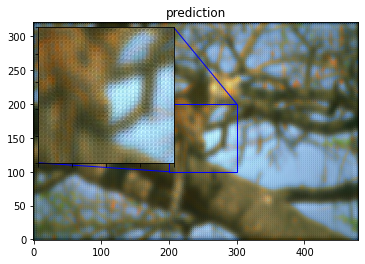

25/25 - 27s - loss: 0.0249 - val_loss: 0.0104 - 27s/epoch - 1s/step


Epoch 2/100
Mean PSNR for epoch: 22.22
25/25 - 26s - loss: 0.0074 - val_loss: 0.0059 - 26s/epoch - 1s/step


Epoch 3/100
Mean PSNR for epoch: 23.83
25/25 - 26s - loss: 0.0047 - val_loss: 0.0042 - 26s/epoch - 1s/step


Epoch 4/100
Mean PSNR for epoch: 25.03
25/25 - 26s - loss: 0.0037 - val_loss: 0.0034 - 26s/epoch - 1s/step


Epoch 5/100
Mean PSNR for epoch: 25.02
25/25 - 26s - loss: 0.0032 - val_loss: 0.0032 - 26s/epoch - 1s/step


Epoch 6/100
Mean PSNR for epoch: 25.19
25/25 - 26s - loss: 0.0030 - val_loss: 0.0030 - 26s/epoch - 1s/step


Epoch 7/100
Mean PSNR for epoch: 25.14
25/25 - 26s - loss: 0.0029 - val_loss: 0.0030 - 26s/epoch - 1s/step


Epoch 8/100
Mean PSNR for epoch: 25.77
25/25 - 26s - loss: 0.0028 - val_loss: 0.0029 - 26s/epoch - 1s/step


Epoch 9/100
Mean PSNR for epoch: 25.30
25/25 - 26s - loss: 0.0028 - val_loss: 0.0029 - 26s/epoch - 1s/step


Epoch 10/100
Mean PSNR for epoch: 25.34
25/25 - 26s - loss

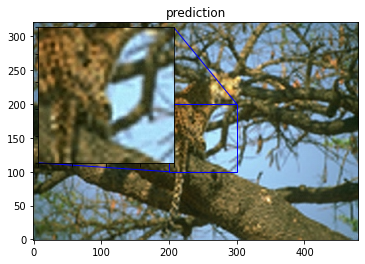

25/25 - 28s - loss: 0.0026 - val_loss: 0.0027 - 28s/epoch - 1s/step


Epoch 22/100
Mean PSNR for epoch: 25.55
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 23/100
Mean PSNR for epoch: 25.65
25/25 - 27s - loss: 0.0026 - val_loss: 0.0027 - 27s/epoch - 1s/step


Epoch 24/100
Mean PSNR for epoch: 25.32
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 25/100
Mean PSNR for epoch: 25.68
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 26/100
Mean PSNR for epoch: 25.15
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 27/100
Mean PSNR for epoch: 25.45
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 28/100
Mean PSNR for epoch: 26.19
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 29/100
Mean PSNR for epoch: 25.46
25/25 - 26s - loss: 0.0026 - val_loss: 0.0027 - 26s/epoch - 1s/step


Epoch 30/100
Mean PSNR for epoch: 25.83
25/25 - 26

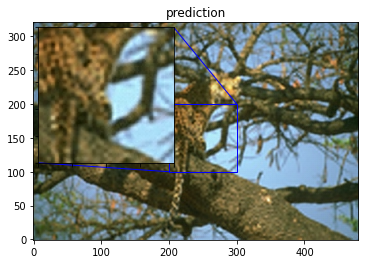

25/25 - 27s - loss: 0.0027 - val_loss: 0.0027 - 27s/epoch - 1s/step


Epoch 42/100
Mean PSNR for epoch: 25.89
25/25 - 26s - loss: 0.0026 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 43/100
Mean PSNR for epoch: 25.58
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 44/100
Mean PSNR for epoch: 25.49
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 45/100
Mean PSNR for epoch: 25.65
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 46/100
Mean PSNR for epoch: 25.44
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 47/100
Mean PSNR for epoch: 25.66
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 48/100
Mean PSNR for epoch: 25.78
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 49/100
Mean PSNR for epoch: 25.69
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 50/100
Mean PSNR for epoch: 25.72
25/25 - 26

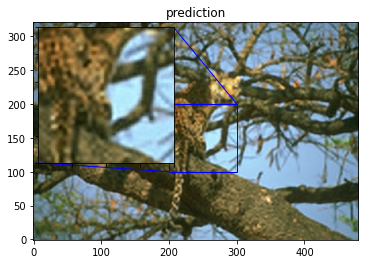

25/25 - 27s - loss: 0.0025 - val_loss: 0.0026 - 27s/epoch - 1s/step


Epoch 62/100
Mean PSNR for epoch: 25.65
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 63/100
Mean PSNR for epoch: 26.09
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 64/100
Mean PSNR for epoch: 25.52
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 65/100
Mean PSNR for epoch: 25.97
25/25 - 26s - loss: 0.0025 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 66/100
Mean PSNR for epoch: 25.81
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 67/100
Mean PSNR for epoch: 26.16
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 68/100
Mean PSNR for epoch: 25.88
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 69/100
Mean PSNR for epoch: 25.74
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 70/100
Mean PSNR for epoch: 25.53
25/25 - 26

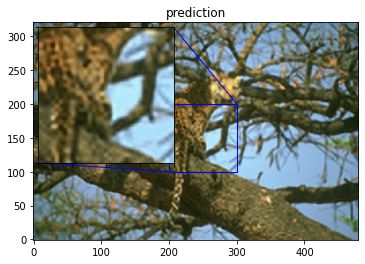

25/25 - 27s - loss: 0.0024 - val_loss: 0.0026 - 27s/epoch - 1s/step


Epoch 82/100
Mean PSNR for epoch: 25.79
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 83/100
Mean PSNR for epoch: 26.19
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 84/100
Mean PSNR for epoch: 25.77
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 85/100
Mean PSNR for epoch: 26.08
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 86/100
Mean PSNR for epoch: 25.78
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 87/100
Mean PSNR for epoch: 25.72
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 88/100
Mean PSNR for epoch: 25.65
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 89/100
Mean PSNR for epoch: 26.02
25/25 - 26s - loss: 0.0024 - val_loss: 0.0026 - 26s/epoch - 1s/step


Epoch 90/100
Mean PSNR for epoch: 24.15
25/25 - 26

In [ ]:
epochs = 100
callbacks = [ESPCNCallback(), early_stopping_callback, model_checkpoint_callback]

history = model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=valid_ds, verbose=2)

# On enregistre l'historique des loss à la fin de l'apprentissage
with open(os.path.join(PATH_FOR_HISTORY, 'trainHistoryDict'), 'wb') as file_pi:
  pickle.dump(history.history, file_pi)

### Historique des loss

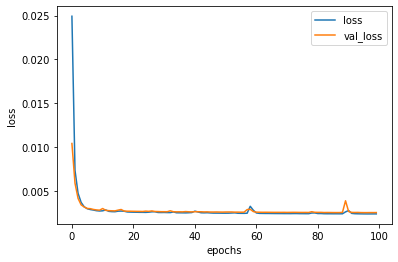

In [ ]:
history = pickle.load(open(os.path.join(PATH_FOR_HISTORY, 'trainHistoryDict'), 'rb'))

loss = history["loss"]
val_loss = history["val_loss"]
epochs = range(len(loss))

plt.plot(epochs, loss, label="loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

## Résultats

### Chargement du meilleur modèle

Grâce au fichier généré par `model_checkpoint_callback`, on peut à tout moment recharger notre modèle avec les meilleurs paramètres retenus pendant l'entraînement.

In [ ]:
model = get_model(upscale_factor=upscale_factor, channels=1)
model.load_weights(checkpoint_filepath)

### Quelques prédictions sur des images test

PSNR of low resolution image and high resolution image is 30.3819
PSNR of predict and high resolution is 31.0323


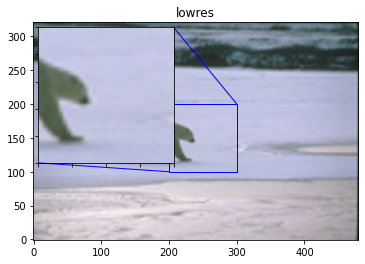

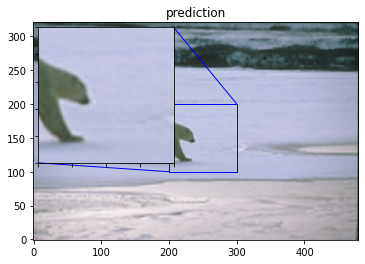

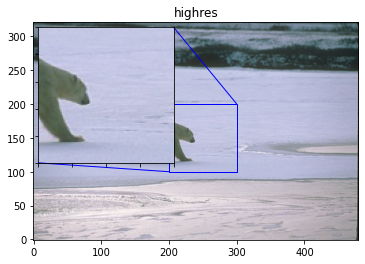

PSNR of low resolution image and high resolution image is 23.7337
PSNR of predict and high resolution is 24.1072


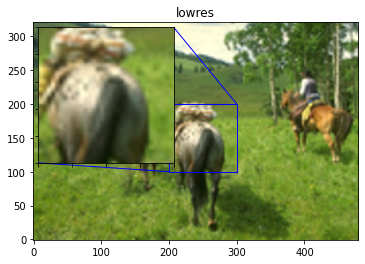

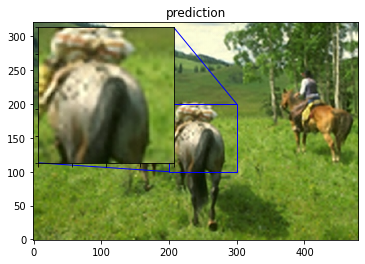

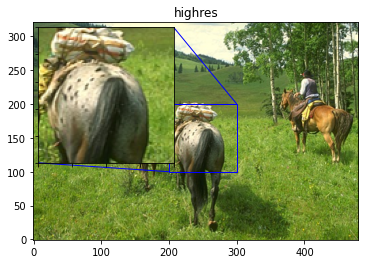

PSNR of low resolution image and high resolution image is 24.2051
PSNR of predict and high resolution is 24.9805


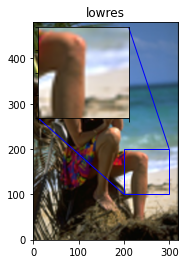

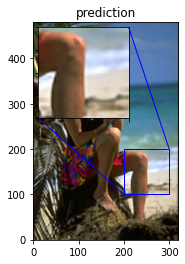

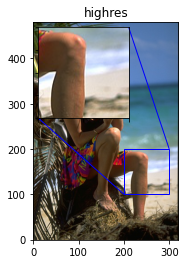

PSNR of low resolution image and high resolution image is 26.8143
PSNR of predict and high resolution is 27.5067


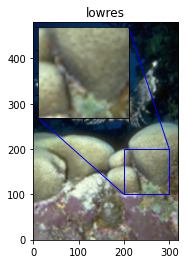

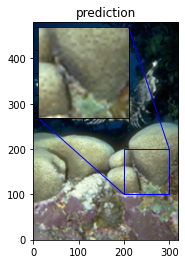

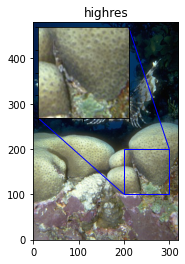

PSNR of low resolution image and high resolution image is 26.9181
PSNR of predict and high resolution is 27.6506


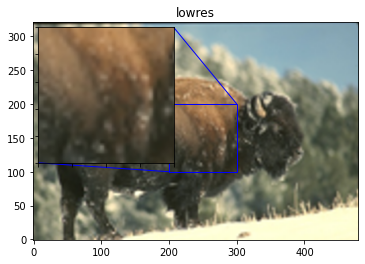

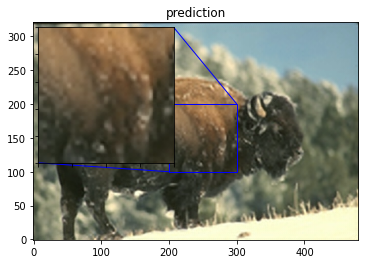

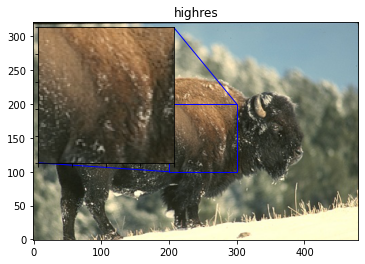

PSNR of low resolution image and high resolution image is 19.6810
PSNR of predict and high resolution is 20.4505


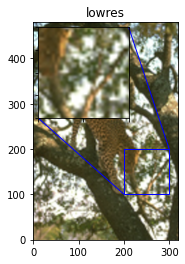

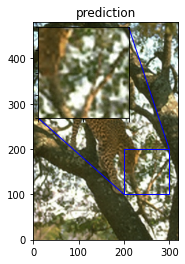

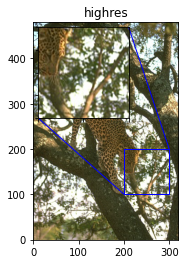

PSNR of low resolution image and high resolution image is 28.5374
PSNR of predict and high resolution is 28.9121


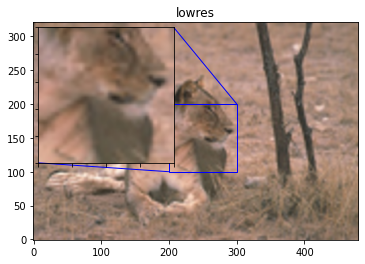

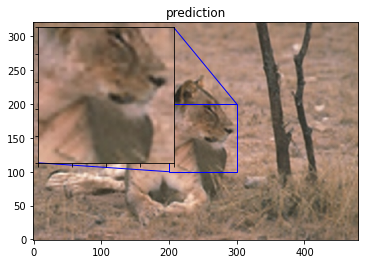

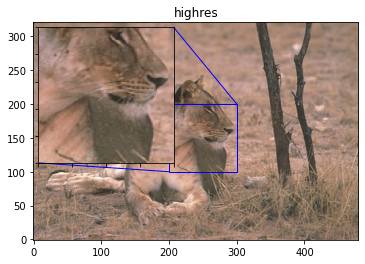

PSNR of low resolution image and high resolution image is 28.4484
PSNR of predict and high resolution is 29.3570


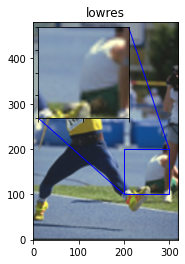

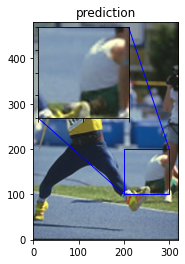

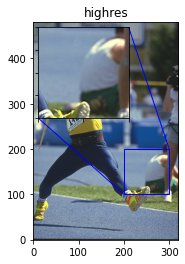

PSNR of low resolution image and high resolution image is 24.8439
PSNR of predict and high resolution is 25.6832


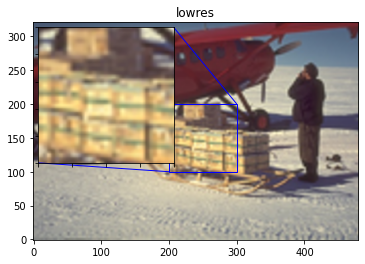

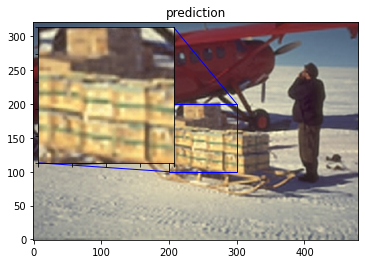

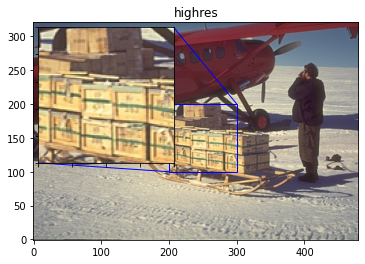

PSNR of low resolution image and high resolution image is 28.2110
PSNR of predict and high resolution is 29.2973


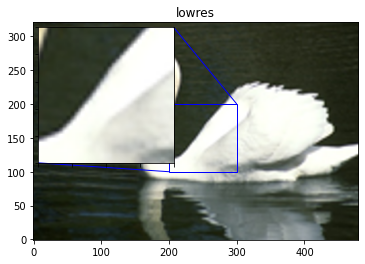

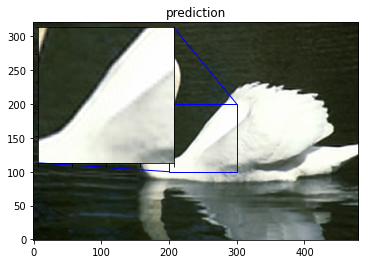

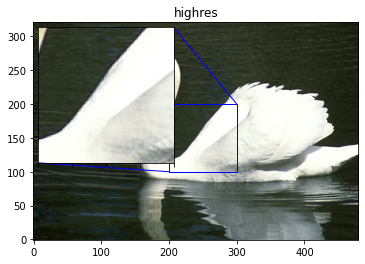

Avg. PSNR of lowres images is 26.1775
Avg. PSNR of reconstructions is 26.8977


In [ ]:
total_bicubic_psnr = 0.0
total_test_psnr = 0.0

for index, test_img_path in enumerate(test_img_paths[50:60]):

    img = load_img(test_img_path)
    lowres_input = get_lowres_image(img, upscale_factor)
    w = lowres_input.size[0] * upscale_factor
    h = lowres_input.size[1] * upscale_factor
    highres_img = img.resize((w, h))
    prediction = upscale_image(model, lowres_input)
    lowres_img = lowres_input.resize((w, h))
    lowres_img_arr = img_to_array(lowres_img)
    highres_img_arr = img_to_array(highres_img)
    predict_img_arr = img_to_array(prediction)
    bicubic_psnr = tf.image.psnr(lowres_img_arr, highres_img_arr, max_val=255)
    test_psnr = tf.image.psnr(predict_img_arr, highres_img_arr, max_val=255)

    total_bicubic_psnr += bicubic_psnr
    total_test_psnr += test_psnr

    print(
        "PSNR of low resolution image and high resolution image is %.4f" % bicubic_psnr
    )
    print("PSNR of predict and high resolution is %.4f" % test_psnr)
    plot_results(lowres_img, index, "lowres")
    plot_results(prediction, index, "prediction")
    plot_results(highres_img, index, "highres")

print("Avg. PSNR of lowres images is %.4f" % (total_bicubic_psnr / 10))
print("Avg. PSNR of reconstructions is %.4f" % (total_test_psnr / 10))

### Quelques prédictions sur des images personnalisées

In [ ]:
patio_highres = load_img(os.path.join(DIR_FOR_DATA, "datasets", "patio_highres.jpg"))
patio_petit = load_img(os.path.join(DIR_FOR_DATA, "datasets", "patio_petit.jpg"))
patio_rikiki = load_img(os.path.join(DIR_FOR_DATA, "datasets", "patio_rikiki.jpg"))
patio_mega_rikiki = load_img(os.path.join(DIR_FOR_DATA, "datasets", "patio_mega_rikiki.jpg"))

trousse_highres = load_img(os.path.join(DIR_FOR_DATA, "datasets", "trousse_highres.jpg"))
trousse_petit = load_img(os.path.join(DIR_FOR_DATA, "datasets", "trousse_petit.jpg"))
trousse_rikiki = load_img(os.path.join(DIR_FOR_DATA, "datasets", "trousse_rikiki.jpg"))
trousse_mega_rikiki = load_img(os.path.join(DIR_FOR_DATA, "datasets", "trousse_mega_rikiki.jpg"))

print("highres :", patio_highres.size)
print("petit :", patio_petit.size)
print("rikiki :", patio_rikiki.size)
print("mega_rikiki :", patio_mega_rikiki.size)

highres : (1236, 927)
petit : (300, 225)
rikiki : (200, 150)
mega_rikiki : (100, 75)


In [ ]:
old_size = patio_highres.size
scale = 0.4
disp_size = (int(scale*old_size[0]), int(scale*old_size[1]))

patio_todo = patio_rikiki
trousse_todo = trousse_rikiki
prediction_patio = upscale_image(model, patio_todo)
prediction_trousse = upscale_image(model, trousse_todo)

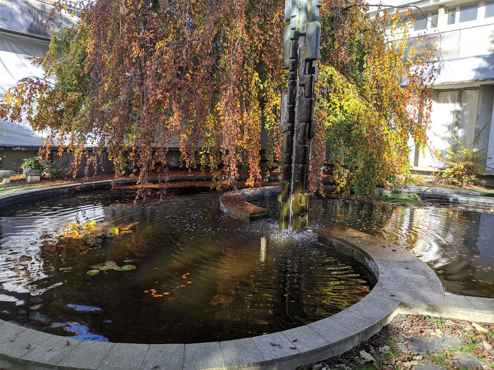

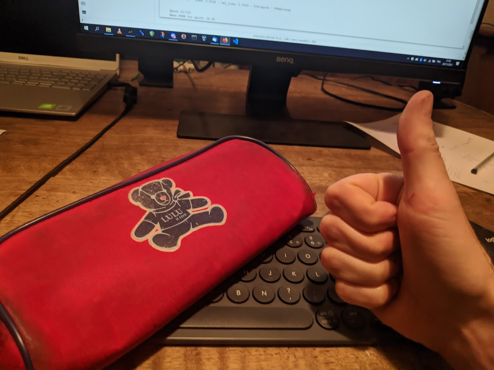

In [ ]:
display(patio_highres.resize(disp_size, PIL.Image.BICUBIC))
display(trousse_highres.resize(disp_size, PIL.Image.BICUBIC))

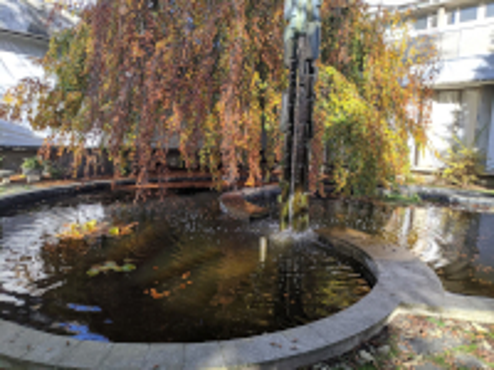

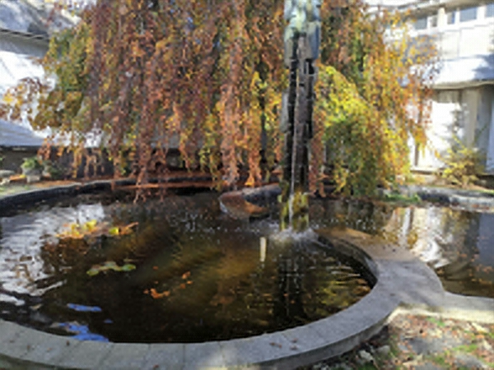

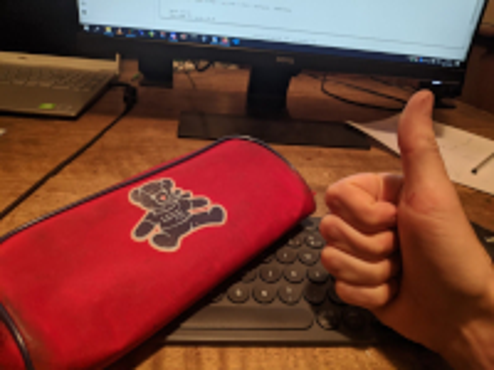

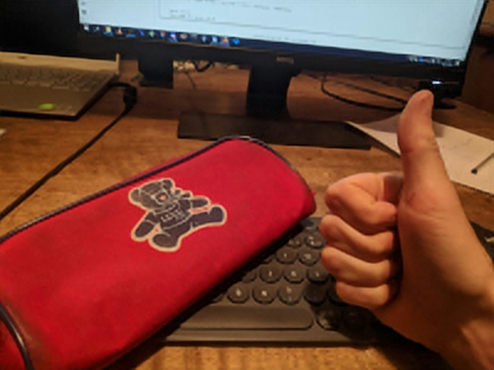

In [ ]:
display(patio_todo.resize(disp_size, PIL.Image.BICUBIC))
display(prediction_patio.resize(disp_size, PIL.Image.BICUBIC))


display(trousse_todo.resize(disp_size, PIL.Image.BICUBIC))
display(prediction_trousse.resize(disp_size, PIL.Image.BICUBIC))